In [1]:
import os
import shutil
from pathlib import Path

import pyvista as pv
import ogstools as ot
import ogstools.variables as ov

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from meshing import create_cube_mesh_p
from functions_s import pd_ps,step_rate_s

# STIMTEC Example

## Path adjoint

In [2]:
OGS_PATH = None

if OGS_PATH is not None:
    os.environ["OGS_BIN_PATH"] = OGS_PATH
OUT_DIR = Path(os.environ.get("OGS_TESTRUNNER_OUT_DIR", "_out_ps"))
MESH_DIR = OUT_DIR / "mesh"
shutil.rmtree(OUT_DIR, ignore_errors=True)
MESH_DIR.mkdir(parents=True, exist_ok=True)

## Point-source step-rate

### Preprocesing and preparing data

In [3]:
cwd=Path.cwd()
newpath=cwd/"STIMTEC_example"
TESTSR= 'BH10_20180716_51.6.csv'
dataex_f=pd.read_csv(newpath/"BH10_20180716_51.6_SR.csv",sep=",",header=0)
protocol=pd.read_csv(newpath/"protocol_SR.csv", sep=",",header=0)

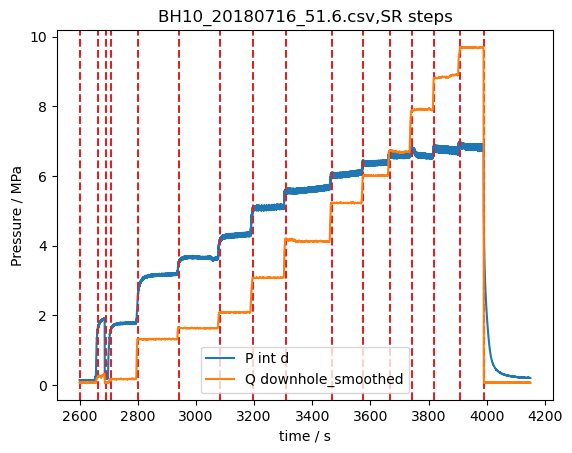

In [4]:
fig3, ax=plt.subplots()

ax.set_xlabel("time / s")
ax.set_ylabel("Pressure / MPa")
plt.title(f"{TESTSR},SR steps")

ax.plot(dataex_f['Zeit [s]'],dataex_f['Pint_downhole [MPa]'],label="P int d")
for i in range (len(protocol)):
     ax.axvline(x=dataex_f.loc[protocol.iloc[i,0],'Zeit [s]'],ls="--",color="tab:red")
ax.plot(dataex_f['Zeit [s]'],dataex_f['Q_downhole [lpm]_s'],label="Q downhole_smoothed")

plt.legend()
plt.show()

### Point-source analytical running

In [5]:
#data 
ddict={"p_i":0,
       "mu":1e-3 ,
       "B":1,
       "por":0.030,
       "c_t":4e-8 ,
       "r_w":0.038 
      }

delta_t=dataex_f['Zeit [s]'].values
tp=protocol['T_s [s]'].values
q_array=protocol['qs [m**/s]'].values

k_val=4.5e-14 #reference k

rgeo=np.geomspace(0.038,5,5)
r_val=rgeo
pwsr2= step_rate_s(pd_ps, delta_t, tp, q_array, ddict, k_val, r_val)

rinv=np.sqrt(k_val*(max(dataex_f['Zeit [s]'])-min(dataex_f['Zeit [s]']))/(ddict['por']*ddict['mu']*ddict['c_t']))
print("Investigation radius (m): ",f"{rinv:.2f}",'\n','"unperturbed" threshold (m): ', f"{4*rinv:.2f}")

Investigation radius (m):  7.62 
 "unperturbed" threshold (m):  30.50


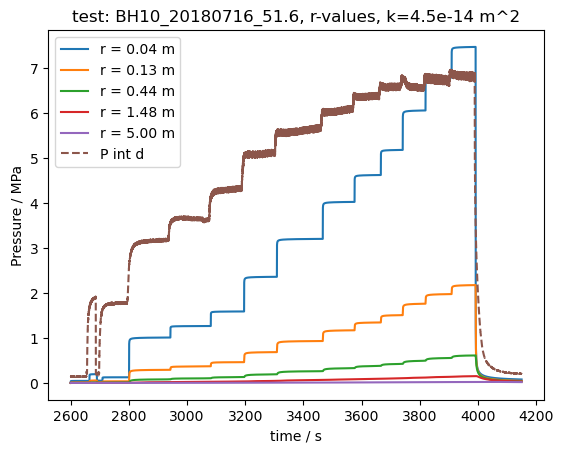

In [6]:
line_labels = [f"r = {val:>5.2f} m" for val in rgeo]

fig5, ax=plt.subplots()

for i, r in enumerate(rgeo):
    plt.plot(delta_t, pwsr2[:, i]/1e6, label=f'r = {r:.2f} m')
ax.plot(dataex_f['Zeit [s]'],dataex_f['Pint_downhole [MPa]'],label="P int d", ls="--")

ax.set_xlabel("time / s")
ax.set_ylabel("Pressure / MPa")
plt.title(f"test: BH10_20180716_51.6, r-values, k={k_val} m^2")

plt.legend() 
plt.pause(1)

## Point-source Numerical

### Meshing 3D point-source

In [7]:
cube_file = MESH_DIR / "cube_3d_ps.msh"

create_cube_mesh_p(
    cube_file,
    width= 50,
    height= 50,
    thickness=50,
    mesh_size= 2, #optimal one-size-to-mesh ratio= 20-40, ie, side(50)/mesh_size(2)=25, ref 1
    target_rw= 0.05, # Added target_rw for explicit control
    center_z= -50,
    debug_gui= False,
    local_ref= True,
    ) 

cube_meshes = ot.meshes_from_gmsh(cube_file, log=False)
for name, mesh in cube_meshes.items():
    vtu = MESH_DIR / f"cube_{name}.vtu"
    pv.save_meshio(vtu, mesh)
    print(f"Saved {vtu}")


Saved _out_ps\mesh\cube_domain.vtu
Saved _out_ps\mesh\cube_physical_group_points.vtu
Saved _out_ps\mesh\cube_physical_group_center.vtu
Saved _out_ps\mesh\cube_physical_group_edges.vtu
Saved _out_ps\mesh\cube_physical_group_bottom.vtu
Saved _out_ps\mesh\cube_physical_group_top.vtu
Saved _out_ps\mesh\cube_physical_group_back.vtu
Saved _out_ps\mesh\cube_physical_group_front.vtu
Saved _out_ps\mesh\cube_physical_group_left.vtu
Saved _out_ps\mesh\cube_physical_group_right.vtu
Saved _out_ps\mesh\cube_physical_group_volume.vtu


### Running OGS

In [10]:
!ogs ./BH10_20180716_51.6_PS3D.prj -m ./_out_ps/mesh -o ./_out_ps/

info: This is OpenGeoSys-6 version 6.5.5.
info: OGS started on 2026-04-09 17:26:13+0200.
info: Eigen use 16 threads
info: Reading project file BH10_20180716_51.6_PS3D.prj.
info: readRasters ...
info: readRasters done
info: ConstantParameter: p0
info: ConstantParameter: pi_inf
info: ConstantParameter: constant_porosity_parameter
info: FunctionParameter: q_in
info: Initialize processes.
info: Time step #0 started. Time: 2600.023. Step size: 0.
info: [time] Output of timestep 0 took 0.515735 s.
info: Time step #0 took 0.580323 s.
info: OpenGeoSys is now initialized.
info: OGS started on 2026-04-09 17:26:16+0200.
info: Solve processes.
info: Time step #1 started. Time: 2600.123. Step size: 0.10000000000000001.
info: Solving process #0 started.
info: Iteration #1 started.
info: [time] Assembly took 0.413323 s.
info: [time] Applying Dirichlet BCs took 0.011305 s.
info: ------------------------------------------------------------------
info: *** Eigen solver compute()
info: -> compute with Ei

## Results and visualization

### Post-processing 

In [11]:
pvd_path = Path("_out_ps/BH10_20180716_51.6.pvd")
ms = ot.MeshSeries(pvd_path)
pressure=ot.variables.pressure
pressure= pressure.replace(output_unit="MPa")

In [12]:
y=25
z=-50

np.geomspace(0.038,5,5)

coords=np.array(np.linspace([25,y,z],[50,y,z],5)) #extracting along x linearly
coords[:,0]=rgeo+25 #adjusting geometry shifting
ms_probes = ms.extract_probe(ms,points=coords)

labels = [f"x={pt[0]:>5.2f}, y={y}, z={z}" for pt in coords]

pwsr2p= step_rate_s(pd_ps, ms_probes.timevalues, tp, q_array, ddict, k_val, r_val) #diff by time resolution
diff = pwsr2p - ms_probes['pressure']


100%|████████████████████████████████████████████████████████████████████████████████| 166/166 [00:15<00:00, 10.92it/s]


### Analytical and Numerical OGS comparison

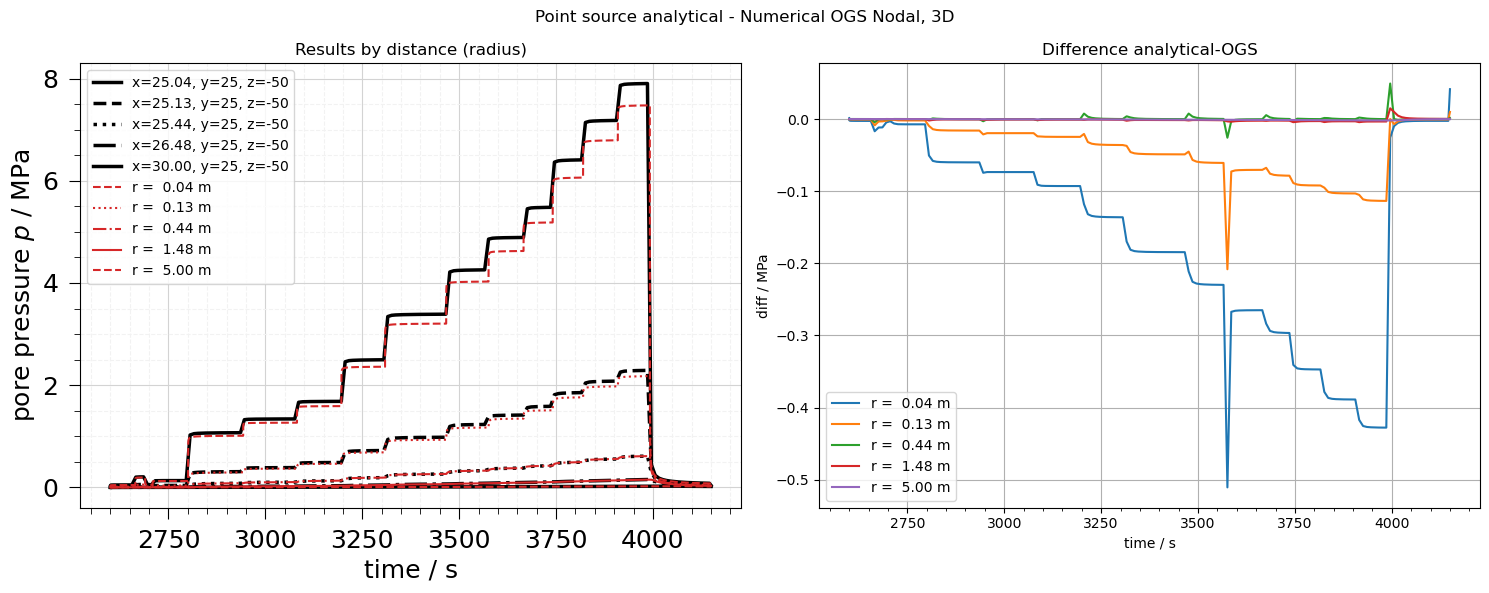

In [13]:
t=dataex_f['Zeit [s]']

fig7, axs= plt.subplots(nrows=1, ncols=2,figsize=[15,6], sharex=True)
ot.plot.line(ms_probes,"time", pressure,ax=axs[0], color='k',fontsize=18,label=labels)
axs[0].plot(t, pwsr2/1e6,color='tab:red', label=line_labels) 
axs[1].plot(ms_probes.timevalues, diff/1e6, label=line_labels)

fig7.suptitle("Point source analytical - Numerical OGS Nodal, 3D") 
axs[0].set_title("Results by distance (radius)")
axs[1].set_title("Difference analytical-OGS")
axs[1].set_xlabel("time / s")
axs[1].set_ylabel("diff / MPa")

axs[0].legend()
axs[1].legend()
axs[1].grid()
plt.tight_layout()

#plt.savefig("psn_3D_BH10_20180716_51.6.pdf", format="pdf") 
plt.show()

**NOTE: Numerical difference is due to mesh and rw relations.
The specific storage capacity (OGS) scaling is equal to $$s=c* \phi, \quad \left[\mathrm{Pa^{-1}}\right]$$, the scaling for the flow is $$r_{\mathrm{eq}} = (3 * LV / (4 \pi))^{1/3}$$ 
$$q_{\mathrm{fact}}=(1/r_{\mathrm{eq}})^{2/3}$$ 
$$q_{\mathrm{num}}=q_{\mathrm{fact}} \, q_{\mathrm{an}}$$ 
Where $LV$ is the local volume of the first ring of elements in around the node source; $q_{\mathrm{num}}\, , q_{\mathrm{fact}} \, , q_{\mathrm{an}}$, are the numerical (for OGS), factor, and analytical flow input.